rows: 71361
agents: 564
time range: 3700.0 to 3900.0
type codes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]
   type           type_name  agents  avg_speed  max_speed  avg_accel  \
0     0         Pedestrians     380   1.139820   1.381566   0.014284   
1     1            Bicycles       8   2.210734   3.307644  -0.022063   
2     2            Scooters       8   3.735626   4.316470   0.132820   
3     3      Passenger Cars     157   6.331613  10.102264   0.021532   
4     4  Automated Vehicles       1   2.470593   7.281703   0.009448   
5     5         Motorcycles       1   5.381609   5.961273  -0.073597   
6     6               Buses       2   2.041217   7.384732   0.085466   
7     7              Trucks       7   4.087275   5.547321  -0.024765   

   avg_decel_events  avg_hard_decel_events  
0          0.000000               0.000000  
1          0.250000               0.000000  
2          0.000000               0.000000  
3

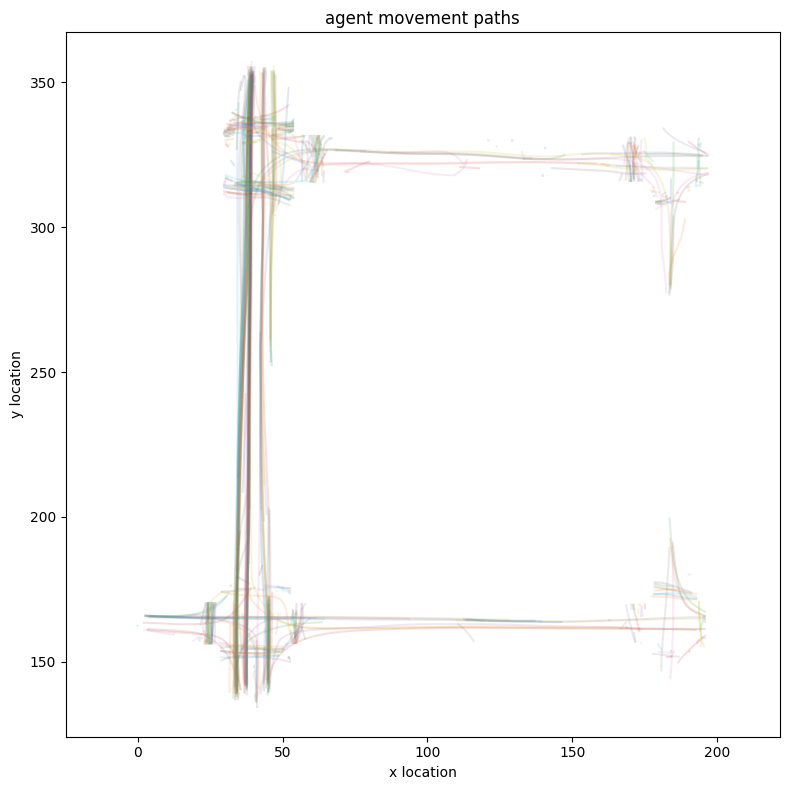

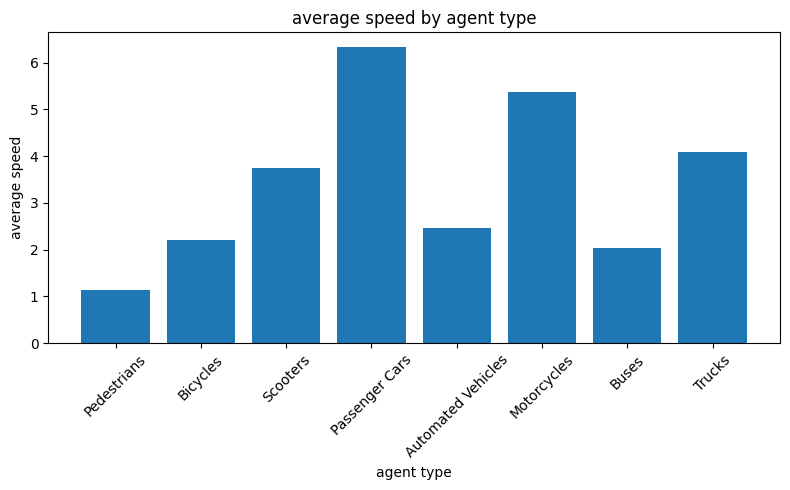

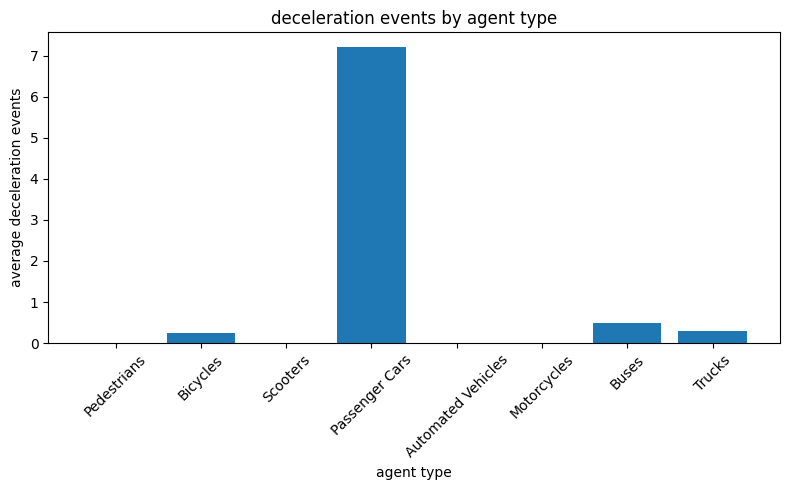

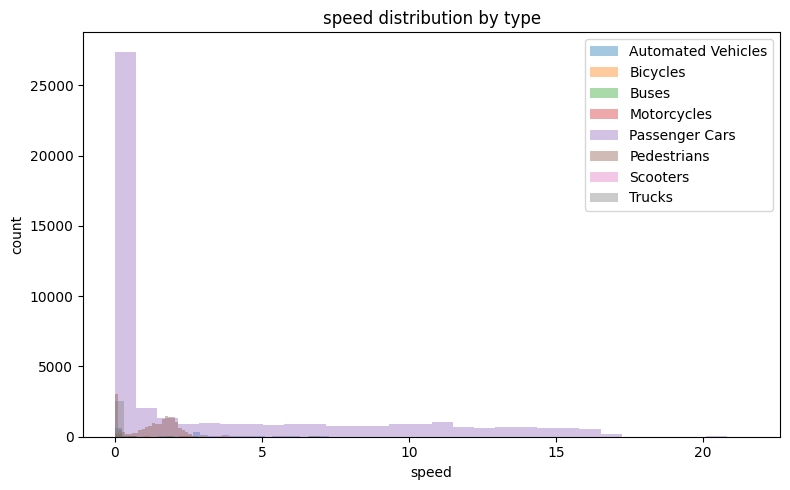

   type_most_common           type_name  points  agents  avg_speed  avg_accel  \
0                 0         Pedestrians    1483      40   1.485708   0.086692   
1                 1            Bicycles      13       2   3.793117   1.434495   
2                 2            Scooters      13       2   3.434703   0.935685   
3                 3      Passenger Cars    1688      14   1.927028   0.027805   
4                 4  Automated Vehicles       3       1   6.471044  -0.982383   
5                 6               Buses     373       2   0.589319   0.154256   

   decel_events  hard_decel_events  
0             0                  0  
1             0                  0  
2             0                  0  
3            27                  0  
4             0                  0  
5             0                  0  


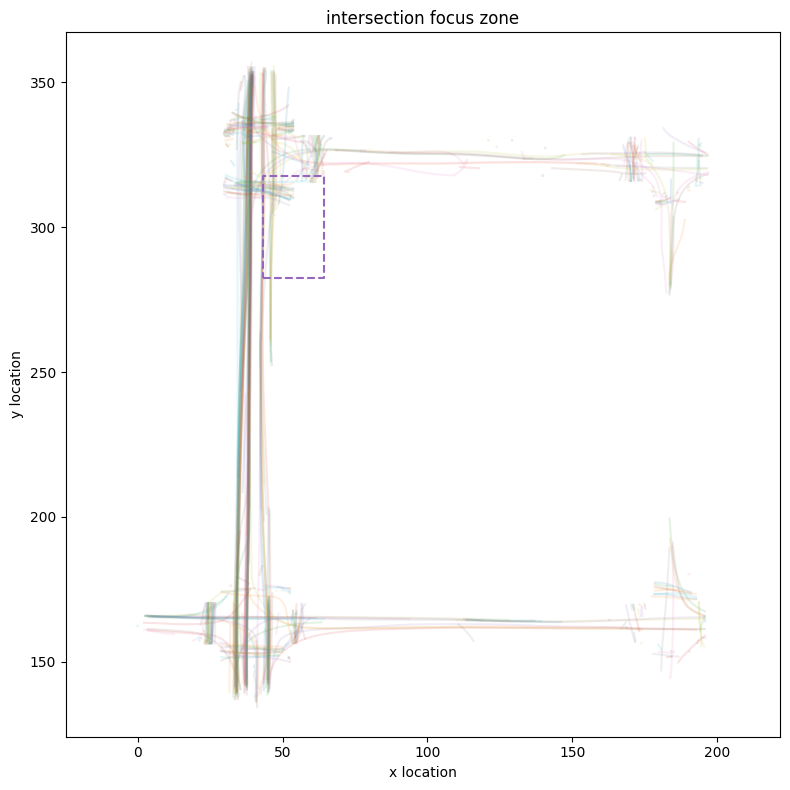

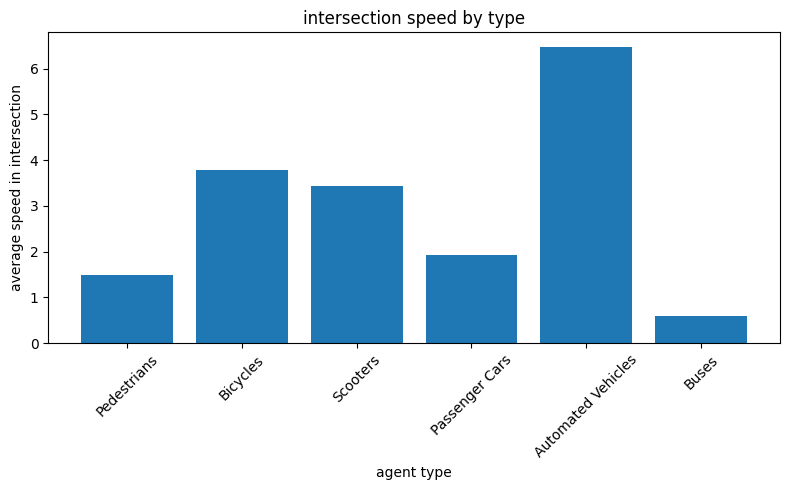

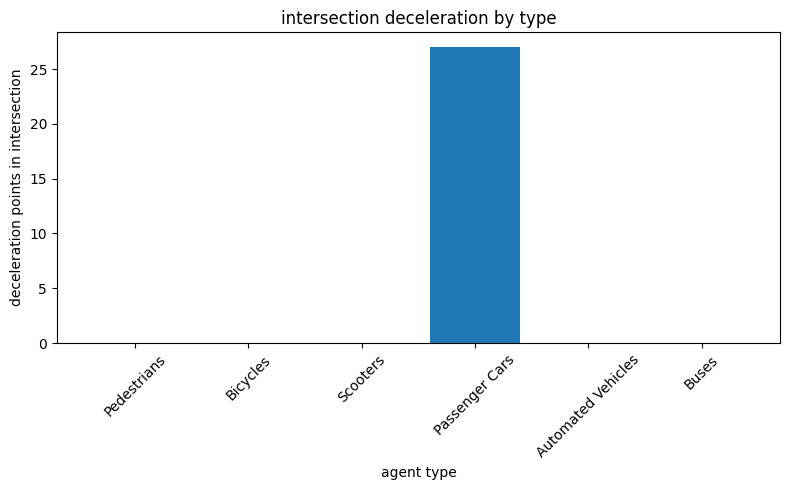

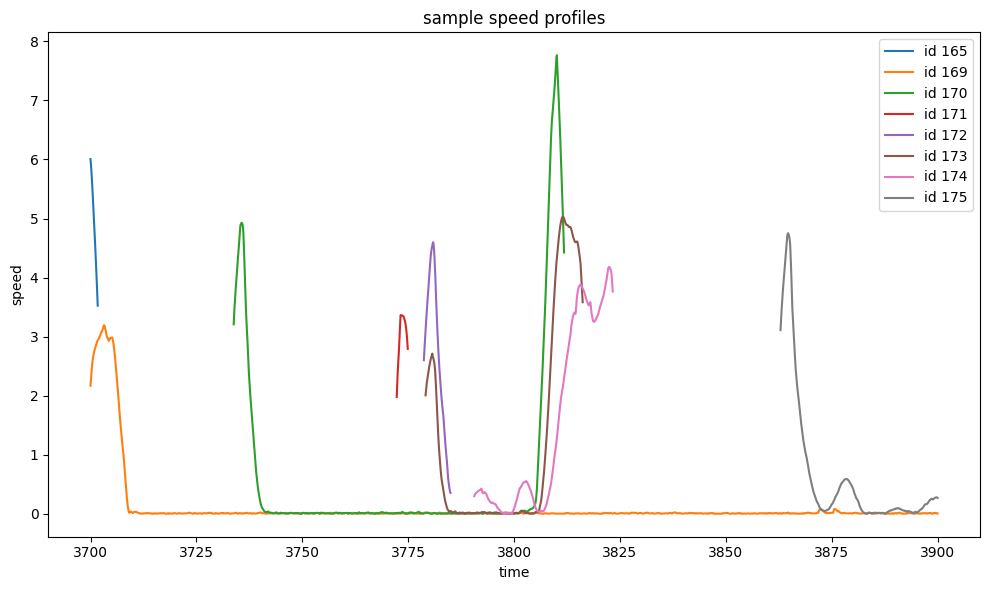

  av_group  agents  avg_speed  avg_accel  decel_events  hard_decel_events
0       av       1   2.470593   0.009448             0                  0
1   non-av     563   2.610957   0.021669          1137                 10


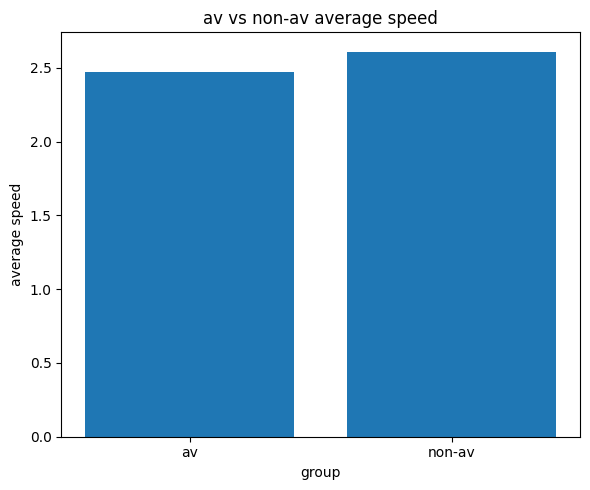

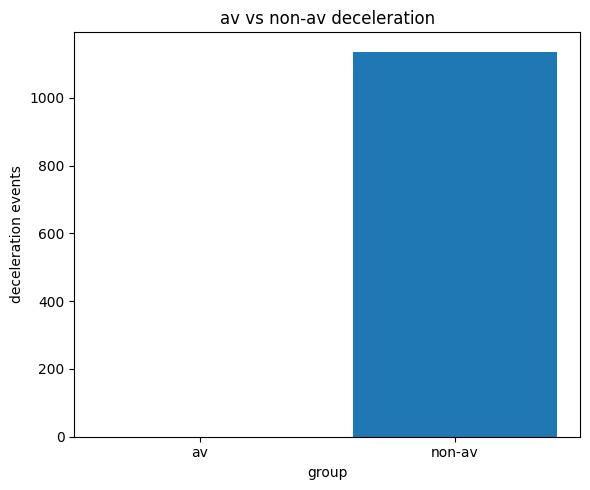

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("Transformed_TGSIM_Foggy_Bottom_200sec.csv")
df = df.sort_values(["id", "time"])

# update this after checking the data dictionary
type_names = {
    0: "Pedestrians",
    1: "Bicycles",
    2: "Scooters",
    3: "Passenger Cars",
    4: "Automated Vehicles",
    5: "Motorcycles",
    6: "Buses",
    7: "Trucks"
}

# update this once you know which code is AV
av_types = [4]

df["type_name"] = df["type_most_common"].map(type_names)

df["speed"] = np.sqrt(df["speed_kf_x"]**2 + df["speed_kf_y"]**2)

df["dt"] = df.groupby("id")["time"].diff()
df["ds"] = df.groupby("id")["speed"].diff()
df["accel"] = df["ds"] / df["dt"]

df["decel"] = df["accel"] < -3
df["hard_decel"] = df["accel"] < -6

print("rows:", len(df))
print("agents:", df["id"].nunique())
print("time range:", df["time"].min(), "to", df["time"].max())
print("type codes:", sorted(df["type_most_common"].unique()))

agent_summary = df.groupby("id").agg(
    type=("type_most_common", "first"),
    type_name=("type_name", "first"),
    mean_speed=("speed", "mean"),
    max_speed=("speed", "max"),
    mean_accel=("accel", "mean"),
    min_accel=("accel", "min"),
    decel_events=("decel", "sum"),
    hard_decel_events=("hard_decel", "sum")
).reset_index()

type_summary = agent_summary.groupby(["type", "type_name"]).agg(
    agents=("id", "count"),
    avg_speed=("mean_speed", "mean"),
    max_speed=("max_speed", "mean"),
    avg_accel=("mean_accel", "mean"),
    avg_decel_events=("decel_events", "mean"),
    avg_hard_decel_events=("hard_decel_events", "mean")
).reset_index()

print(type_summary)

agent_summary.to_csv("agent_summary.csv", index=False)
type_summary.to_csv("type_summary.csv", index=False)

plt.figure(figsize=(8, 8))
for _, g in df.groupby("id"):
    plt.plot(g["xloc_kf"], g["yloc_kf"], alpha=0.15)
plt.xlabel("x location")
plt.ylabel("y location")
plt.title("agent movement paths")
plt.axis("equal")
plt.tight_layout()
plt.savefig("movement_paths.png", dpi=300)
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(type_summary["type_name"], type_summary["avg_speed"])
plt.xlabel("agent type")
plt.ylabel("average speed")
plt.title("average speed by agent type")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("average_speed_by_type.png", dpi=300)
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(type_summary["type_name"], type_summary["avg_decel_events"])
plt.xlabel("agent type")
plt.ylabel("average deceleration events")
plt.title("deceleration events by agent type")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("deceleration_by_type.png", dpi=300)
plt.show()

plt.figure(figsize=(8, 5))
for t, g in df.groupby("type_name"):
    plt.hist(g["speed"], bins=30, alpha=0.4, label=t)
plt.xlabel("speed")
plt.ylabel("count")
plt.title("speed distribution by type")
plt.legend()
plt.tight_layout()
plt.savefig("speed_distribution_by_type.png", dpi=300)
plt.show()

xmin = df["xloc_kf"].quantile(0.40)
xmax = df["xloc_kf"].quantile(0.60)
ymin = df["yloc_kf"].quantile(0.40)
ymax = df["yloc_kf"].quantile(0.60)

df["in_intersection"] = (
    (df["xloc_kf"] >= xmin) &
    (df["xloc_kf"] <= xmax) &
    (df["yloc_kf"] >= ymin) &
    (df["yloc_kf"] <= ymax)
)

intersection = df[df["in_intersection"]].copy()

intersection_summary = intersection.groupby(["type_most_common", "type_name"]).agg(
    points=("id", "size"),
    agents=("id", "nunique"),
    avg_speed=("speed", "mean"),
    avg_accel=("accel", "mean"),
    decel_events=("decel", "sum"),
    hard_decel_events=("hard_decel", "sum")
).reset_index()

print(intersection_summary)

intersection_summary.to_csv("intersection_summary.csv", index=False)

plt.figure(figsize=(8, 8))
for _, g in df.groupby("id"):
    plt.plot(g["xloc_kf"], g["yloc_kf"], alpha=0.12)

plt.plot([xmin, xmax, xmax, xmin, xmin],
         [ymin, ymin, ymax, ymax, ymin],
         linestyle="--")

plt.xlabel("x location")
plt.ylabel("y location")
plt.title("intersection focus zone")
plt.axis("equal")
plt.tight_layout()
plt.savefig("intersection_zone.png", dpi=300)
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(intersection_summary["type_name"], intersection_summary["avg_speed"])
plt.xlabel("agent type")
plt.ylabel("average speed in intersection")
plt.title("intersection speed by type")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("intersection_speed_by_type.png", dpi=300)
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(intersection_summary["type_name"], intersection_summary["decel_events"])
plt.xlabel("agent type")
plt.ylabel("deceleration points in intersection")
plt.title("intersection deceleration by type")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("intersection_deceleration_by_type.png", dpi=300)
plt.show()

sample_ids = df["id"].drop_duplicates().head(8)

plt.figure(figsize=(10, 6))
for i in sample_ids:
    g = df[df["id"] == i]
    plt.plot(g["time"], g["speed"], label=f"id {i}")
plt.xlabel("time")
plt.ylabel("speed")
plt.title("sample speed profiles")
plt.legend()
plt.tight_layout()
plt.savefig("sample_speed_profiles.png", dpi=300)
plt.show()

if len(av_types) > 0:
    df["av_group"] = np.where(df["type_most_common"].isin(av_types), "av", "non-av")

    av_summary = df.groupby("av_group").agg(
        agents=("id", "nunique"),
        avg_speed=("speed", "mean"),
        avg_accel=("accel", "mean"),
        decel_events=("decel", "sum"),
        hard_decel_events=("hard_decel", "sum")
    ).reset_index()

    print(av_summary)
    av_summary.to_csv("av_vs_nonav_summary.csv", index=False)

    plt.figure(figsize=(6, 5))
    plt.bar(av_summary["av_group"], av_summary["avg_speed"])
    plt.xlabel("group")
    plt.ylabel("average speed")
    plt.title("av vs non-av average speed")
    plt.tight_layout()
    plt.savefig("av_vs_nonav_speed.png", dpi=300)
    plt.show()

    plt.figure(figsize=(6, 5))
    plt.bar(av_summary["av_group"], av_summary["decel_events"])
    plt.xlabel("group")
    plt.ylabel("deceleration events")
    plt.title("av vs non-av deceleration")
    plt.tight_layout()
    plt.savefig("av_vs_nonav_deceleration.png", dpi=300)
    plt.show()
